In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/churn_data.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
#check how many spaces exist
spaces = df[df['TotalCharges'] == ' ']
print(f"Rows with spaces in TotalCharges: {len(spaces)}")
print(spaces[['tenure', 'MonthlyCharges', 'TotalCharges']])


Rows with spaces in TotalCharges: 11
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             
3331       0           19.85             
3826       0           25.35             
4380       0           20.00             
5218       0           19.70             
6670       0           73.35             
6754       0           61.90             


In [5]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0.0')
df['TotalCharges'] = df['TotalCharges'].astype(float)


In [6]:
print(df.shape)
print(df['TotalCharges'].dtype)
print(df[df['tenure'] == 0.0]['TotalCharges'])


(7043, 21)
float64
488     0.0
753     0.0
936     0.0
1082    0.0
1340    0.0
3331    0.0
3826    0.0
4380    0.0
5218    0.0
6670    0.0
6754    0.0
Name: TotalCharges, dtype: float64


In [7]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
df = df.drop('ToatalCharges', axis=1)

KeyError: "['ToatalCharges'] not found in axis"

In [9]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0.0')
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [10]:
print(df.shape)
print(df.columns.tolist())
print(df['TotalCharges'].dtype)

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
float64


In [11]:
df = df.drop('customerID', axis=1)

In [12]:
print(df.shape)

(7043, 20)


In [13]:
df = df.replace({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].replace({'Male' : 1, 'Female' : 0})


C:\Users\HP\AppData\Local\Temp\ipykernel_32972\3223587187.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Yes': 1, 'No': 0})
C:\Users\HP\AppData\Local\Temp\ipykernel_32972\3223587187.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].replace({'Male' : 1, 'Female' : 0})


In [14]:
print(df['Churn'].value_counts())
print(df['gender'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64
gender
1    3555
0    3488
Name: count, dtype: int64


In [15]:
df = pd.get_dummies(df, drop_first=True)


In [16]:
print(df.shape)
print(df.columns.tolist())

(7043, 31)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_1', 'MultipleLines_No phone service', 'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_1', 'OnlineSecurity_No internet service', 'OnlineBackup_1', 'OnlineBackup_No internet service', 'DeviceProtection_1', 'DeviceProtection_No internet service', 'TechSupport_1', 'TechSupport_No internet service', 'StreamingTV_1', 'StreamingTV_No internet service', 'StreamingMovies_1', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [17]:
print(df.dtypes.value_counts())

bool       21
int64       8
float64     2
Name: count, dtype: int64


In [18]:
df =df.astype({col: int for col in df.select_dtypes(include='bool').columns})

In [19]:
print(df.dtypes.value_counts())

int64      29
float64     2
Name: count, dtype: int64


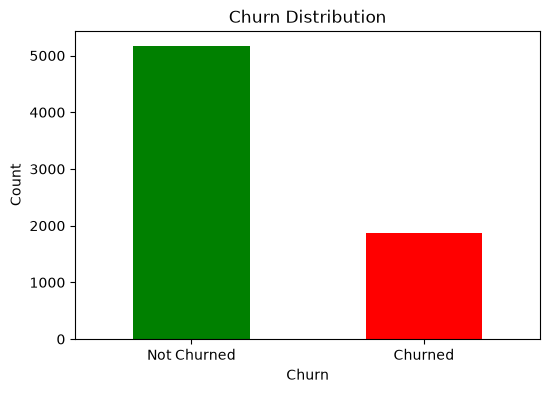

In [20]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Not Churned', 'Churned'], rotation=0)
plt.show()

In [21]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X.shape, y.shape

((7043, 30), (7043,))

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())

(5634, 30)
(1409, 30)
Churn
0    4138
1    1496
Name: count, dtype: int64


In [24]:
from imblearn.over_sampling import BorderlineSMOTE
smote = BorderlineSMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [25]:
print(X_train_balanced.shape)
print(y_train_balanced.value_counts())

(8276, 30)
Churn
0    4138
1    4138
Name: count, dtype: int64


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components= 1)),
    ('classifier', LogisticRegression(max_iter=1000))
]) 

In [27]:
#5 fold cross validation
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(pipeline, X_train_balanced, y_train_balanced, cv = 5, scoring = 'recall')

print(f"cv_scores: {cv_score}")
print(f"Mean_recall: {cv_score.mean():.4f}")
print(f"std recall: {cv_score.std():.4f}")


cv_scores: [0.59541063 0.65296252 0.90931076 0.91545894 0.93719807]
Mean_recall: 0.8021
std recall: 0.1467


In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=1)),
    ('classifier', LogisticRegression(max_iter=1000))
])

cv_score = cross_val_score(pipeline, X_train, y_train,
                           cv=5, scoring='recall')

print(f"CV scores: {cv_score}")
print(f"Mean recall: {cv_score.mean():.4f}")
print(f"Std recall:  {cv_score.std():.4f}")

CV scores: [0.73578595 0.68561873 0.66889632 0.65       0.62541806]
Mean recall: 0.6731
Std recall:  0.0372


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

for name, classifier in classifiers.items():
    pipeline = ImbPipeline([
        ('smote', BorderlineSMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('lda', LinearDiscriminantAnalysis(n_components=1)),
        ('classifier', classifier)
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=5, scoring='recall')
    
    print(f"{name}:")
    print(f"  Mean recall: {cv_scores.mean():.4f}")
    print(f"  Std recall:  {cv_scores.std():.4f}")
    print()

Logistic Regression:
  Mean recall: 0.6731
  Std recall:  0.0372

Random Forest:
  Mean recall: 0.5715
  Std recall:  0.0254

SVM:
  Mean recall: 0.6364
  Std recall:  0.0332



In [30]:
for name, classifier in classifiers.items():
    pipeline = ImbPipeline([
        ('smote', BorderlineSMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', classifier)    # no LDA step
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=5, scoring='recall')
    
    print(f"{name} (no LDA):")
    print(f"  Mean recall: {cv_scores.mean():.4f}")
    print(f"  Std recall:  {cv_scores.std():.4f}")
    print()

Logistic Regression (no LDA):
  Mean recall: 0.6390
  Std recall:  0.0259

Random Forest (no LDA):
  Mean recall: 0.5795
  Std recall:  0.0329

SVM (no LDA):
  Mean recall: 0.6444
  Std recall:  0.0198



with LDA and without LDA with F1 scoring

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

for name, classifier in classifiers.items():
    pipeline = ImbPipeline([
        ('smote', BorderlineSMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('lda', LinearDiscriminantAnalysis(n_components=1)),
        ('classifier', classifier)
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=5, scoring='f1')
    
    print(f"{name}:")
    print(f"  Mean f1: {cv_scores.mean():.4f}")
    print(f"  Std f1:  {cv_scores.std():.4f}")
    print()

Logistic Regression:
  Mean f1: 0.6059
  Std f1:  0.0197

Random Forest:
  Mean f1: 0.5117
  Std f1:  0.0122

SVM:
  Mean f1: 0.6010
  Std f1:  0.0185



In [33]:
for name, classifier in classifiers.items():
    pipeline = ImbPipeline([
        ('smote', BorderlineSMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('classifier', classifier)    # no LDA step
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=5, scoring='f1')
    
    print(f"{name} (no LDA):")
    print(f"  Mean f1: {cv_scores.mean():.4f}")
    print(f"  Std f1:  {cv_scores.std():.4f}")
    print()

Logistic Regression (no LDA):
  Mean f1: 0.5963
  Std f1:  0.0123

Random Forest (no LDA):
  Mean f1: 0.5739
  Std f1:  0.0198

SVM (no LDA):
  Mean f1: 0.5942
  Std f1:  0.0111



In [34]:
from sklearn.model_selection import GridSearchCV

pipeline = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=1)),
    ('classifier', LogisticRegression(max_iter=1000))
])

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(pipeline, param_grid, 
                           cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best F1: {grid_search.best_score_:.4f}")

Best params: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
Best F1: 0.6056


Trying different things to make improvements

In [35]:
final_pipeline = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=1)),
    ('classifier', LogisticRegression(max_iter=1000, C=0.01, solver='lbfgs'))
])

final_pipeline.fit(X_train, y_train)
print("Final pipeline trained successfully!")

Final pipeline trained successfully!


In [36]:
# instead of default 0.5 threshold
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (y_pred_proba >= 0.3).astype(int)  # lower threshold

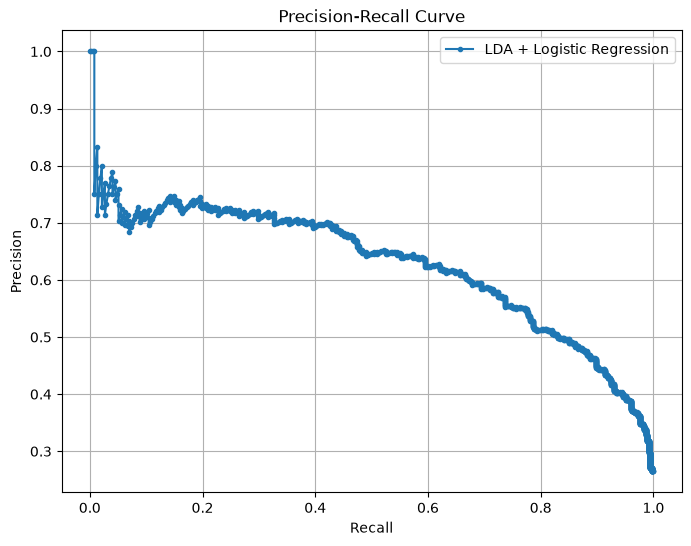

In [37]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Step 1 - train final pipeline
final_pipeline.fit(X_train, y_train)

# Step 2 - get probabilities on test set
# note: SVC needs probability=True to use predict_proba
# LogisticRegression already supports it
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

# Step 3 - compute precision and recall at all thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Step 4 - plot
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='LDA + Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

In [38]:
from sklearn.metrics import f1_score
import numpy as np

# calculate F1 at every threshold
f1_scores = []
for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    f1_scores.append(f1)

# find the threshold with highest F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1:           {best_f1:.4f}")
print(f"Precision at best: {best_precision:.4f}")
print(f"Recall at best:    {best_recall:.4f}")

Optimal threshold: 0.5089
Best F1:           0.6436
Precision at best: 0.5794
Recall at best:    0.7239


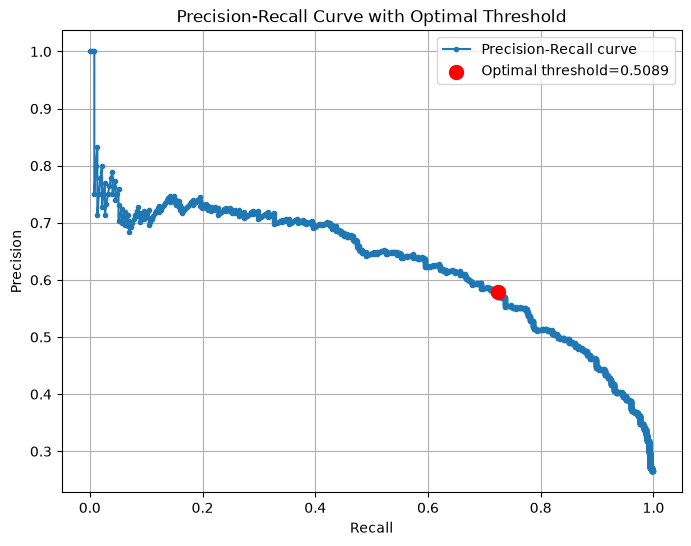

In [39]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Precision-Recall curve')
plt.scatter(best_recall, best_precision, 
            color='red', s=100, zorder=5,
            label=f'Optimal threshold={best_threshold:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Optimal Threshold')
plt.legend()
plt.grid(True)
plt.savefig('precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
from xgboost import XGBClassifier

xgb_pipeline = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=1)),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

# train
xgb_pipeline.fit(X_train, y_train)

# get probabilities
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# find optimal threshold
f1_scores_xgb = []
for threshold in thresholds:
    y_pred = (y_proba_xgb >= threshold).astype(int)
    f1_scores_xgb.append(f1_score(y_test, y_pred))

best_idx_xgb = np.argmax(f1_scores_xgb)
best_threshold_xgb = thresholds[best_idx_xgb]

print(f"XGBoost optimal threshold: {best_threshold_xgb:.4f}")
print(f"XGBoost best F1:           {max(f1_scores_xgb):.4f}")
print(f"XGBoost precision:         {precision[best_idx_xgb]:.4f}")
print(f"XGBoost recall:            {recall[best_idx_xgb]:.4f}")

XGBoost optimal threshold: 0.4609
XGBoost best F1:           0.6366
XGBoost precision:         0.5523
XGBoost recall:            0.7507


In [41]:
# Random Forest threshold tuning
rf_pipeline = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=1)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

f1_scores_rf = []
for threshold in thresholds:
    y_pred = (y_proba_rf >= threshold).astype(int)
    f1_scores_rf.append(f1_score(y_test, y_pred))

best_idx_rf = np.argmax(f1_scores_rf)

print(f"RF optimal threshold: {thresholds[best_idx_rf]:.4f}")
print(f"RF best F1:           {max(f1_scores_rf):.4f}")
print(f"RF precision:         {precision[best_idx_rf]:.4f}")
print(f"RF recall:            {recall[best_idx_rf]:.4f}")

RF optimal threshold: 0.0811
RF best F1:           0.5630
RF precision:         0.3630
RF recall:            0.9732


In [42]:
# SVM threshold tuning
svm_pipeline = ImbPipeline([
    ('smote', BorderlineSMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=1)),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True))
])
svm_pipeline.fit(X_train, y_train)
y_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

f1_scores_svm = []
for threshold in thresholds:
    y_pred = (y_proba_svm >= threshold).astype(int)
    f1_scores_svm.append(f1_score(y_test, y_pred))

best_idx_svm = np.argmax(f1_scores_svm)

print(f"SVM optimal threshold: {thresholds[best_idx_svm]:.4f}")
print(f"SVM best F1:           {max(f1_scores_svm):.4f}")
print(f"SVM precision:         {precision[best_idx_svm]:.4f}")
print(f"SVM recall:            {recall[best_idx_svm]:.4f}")

d:\miniconda3\envs\ML_P\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM optimal threshold: 0.4273
SVM best F1:           0.6436
SVM precision:         0.5310
SVM recall:            0.7802


In [43]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('churn-lda-predictor')

classifiers_results = {
    'Logistic Regression': {
        'f1': 0.6436,
        'recall': 0.7239,
        'precision': 0.5794,
        'threshold': 0.5089,
        'C': 0.01,
        'solver': 'lbfgs'
    },
    'Random Forest': {
        'f1': 0.5630,
        'recall': 0.9732,
        'precision': 0.3630,
        'threshold': 0.0811,
        'n_estimators': 100
    },
    'SVM': {
        'f1': 0.6436,
        'recall': 0.7802,
        'precision': 0.5310,
        'threshold': 0.4273,
        'kernel': 'rbf'
    },
    'XGBoost': {
        'f1': 0.6366,
        'recall': 0.7507,
        'precision': 0.5523,
        'threshold': 0.4609,
        'n_estimators': 100,
        'learning_rate': 0.1
    }
}

for model_name, results in classifiers_results.items():
    with mlflow.start_run(run_name=model_name):
        mlflow.log_param('model', model_name)
        mlflow.log_param('smote', 'BorderlineSMOTE')
        mlflow.log_param('lda_components', 1)
        mlflow.log_metric('f1', results['f1'])
        mlflow.log_metric('recall', results['recall'])
        if results['precision']:
            mlflow.log_metric('precision', results['precision'])
        if results['threshold']:
            mlflow.log_metric('optimal_threshold', results['threshold'])

2026/07/13 02:25:06 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/13 02:25:06 INFO mlflow.store.db.utils: Updating database tables
2026/07/13 02:25:09 INFO mlflow.tracking.fluent: Experiment with name 'churn-lda-predictor' does not exist. Creating a new experiment.


In [45]:
with mlflow.start_run(run_name='final_model_LR'):
    # parameters
    mlflow.log_param('model', 'LogisticRegression')
    mlflow.log_param('smote', 'BorderlineSMOTE')
    mlflow.log_param('lda_components', 1)
    mlflow.log_param('C', 0.01)
    mlflow.log_param('solver', 'lbfgs')
    mlflow.log_param('max_iter', 1000)
    mlflow.log_param('optimal_threshold', 0.5089)
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('cv_folds', 5)

    # metrics
    mlflow.log_metric('f1', 0.6436)
    mlflow.log_metric('recall', 0.7239)
    mlflow.log_metric('precision', 0.5794)

    # save model with joblib
    import joblib
    joblib.dump(final_pipeline, '../models/churn_pipeline.pkl')

    # log artifacts
    mlflow.log_artifact('../models/churn_pipeline.pkl')
    mlflow.log_artifact('precision_recall_curve.png')

    print("Final model logged successfully!")

Final model logged successfully!


In [46]:
print(mlflow.get_tracking_uri())
print(mlflow.get_experiment_by_name('churn-lda-predictor'))

sqlite:///mlflow.db
<Experiment: artifact_location='file:///d:/Master in IB&IV/ML Projects/lda-churn-predictor/notebooks/mlruns/1', creation_time=1783902309266, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783902309266, lifecycle_stage='active', name='churn-lda-predictor', tags={}, trace_location=None, workspace='default'>


In [47]:
import joblib

# save the feature columns after encoding
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, '../models/feature_columns.pkl')
print(feature_columns)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_1', 'MultipleLines_No phone service', 'InternetService_DSL', 'InternetService_Fiber optic', 'OnlineSecurity_1', 'OnlineSecurity_No internet service', 'OnlineBackup_1', 'OnlineBackup_No internet service', 'DeviceProtection_1', 'DeviceProtection_No internet service', 'TechSupport_1', 'TechSupport_No internet service', 'StreamingTV_1', 'StreamingTV_No internet service', 'StreamingMovies_1', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
